# ポイントインタイムのファンダメンタルズ: ASOF ジョインで先読みバイアスを断つ

ファンダメンタルズには時刻が2つあります。数字が対象とする会計期間の日付（`period_end`）と、
市場が実際にそれを知った日付（報告日。通常は25〜55日後）です。データベースを間違ったほうで
索引すると、どのバックテストも、まだ存在しなかった数字で静かに売買することになります。
株式リサーチでいちばんよくあり、いちばん都合よく見えるバグです。このレシピでは、ファンダ
メンタルズを*報告時刻*で保存し、h5i-db の `asof_join` で「直近に報告された EPS」を日次価格
パネルに貼り付け、`period_end` で結合したときに単純な決算シグナルがどれだけ水増しされるかを
定量化し、最後にバージョン固定を使って、訂正が入ったあとも研究を再現できる状態を保ちます。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_pit"), create=True)

## 1. データ: *発表時点*で反応する価格パネル

`make_fundamentals` は現実的な報告ラグを伴う四半期 EPS を生成します。`ts` が報告時刻、
`period_end` が会計期間の日付です。この関数の価格は `make_daily_prices` とは独立に生成
されるので、そのままでは EPS シグナルは何も予測しません。先読みバイアスを*測れる*ように、
肝心な仕組みを1つだけ接ぎ木します。各報告の翌立会日に、株価が EPS サプライズの方向へ4%
（恒久的に）跳ねる、というものです。教科書どおりの発表反応であり、バイアスを正直に実演する
やり方でもあります。情報が価格に織り込まれるのは*公表された時点*であって、四半期が終わった
時点ではありません。

In [2]:
SYMS = [f"STK{i:03d}" for i in range(30)]

funda = cu.make_fundamentals(symbols=SYMS, quarters=10).to_pandas()
funda = funda.sort_values(["symbol", "ts"]).reset_index(drop=True)
funda["eps_growth"] = funda.groupby("symbol")["eps"].pct_change().round(4)

daily = cu.make_daily_prices(symbols=SYMS, days=700).to_pandas()

JUMP = 0.04
for r in funda.dropna(subset=["eps_growth"]).itertuples():
    direction = float(np.sign(r.eps_growth))
    if direction == 0.0:
        continue
    mask = (daily["symbol"] == r.symbol) & (daily["ts"] >= r.ts)
    daily.loc[mask, ["open", "high", "low", "close"]] *= 1 + JUMP * direction

print(f"{len(funda)} reports for {len(SYMS)} symbols, "
      f"{funda['ts'].min():%Y-%m-%d} .. {funda['ts'].max():%Y-%m-%d}")
print(f"{len(daily)} daily rows, {daily['ts'].min():%Y-%m-%d} .. {daily['ts'].max():%Y-%m-%d}")

300 reports for 30 symbols, 2023-04-26 .. 2025-08-23
21000 daily rows, 2023-01-02 .. 2025-09-05


2つの時刻のあいだの隙間が、問題のすべてです。1銘柄について、各四半期の数字は灰色のバーの
長さのあいだ「宙ぶらりん」になります。`period_end` で結合すると、バックテストに数字が
渡るのはバーの*左端*です。市場がそれを見たのは*右端*でした。

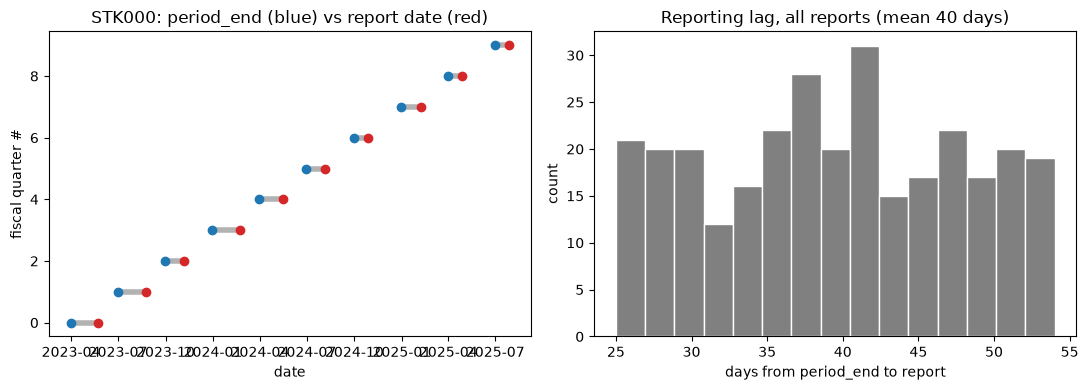

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
f0 = funda[funda["symbol"] == "STK000"].reset_index(drop=True)
for i, r in f0.iterrows():
    axes[0].hlines(i, r["period_end"], r["ts"], color="grey", lw=4, alpha=0.6)
    axes[0].plot(r["period_end"], i, "o", color="tab:blue")
    axes[0].plot(r["ts"], i, "o", color="tab:red")
axes[0].set_title("STK000: period_end (blue) vs report date (red)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("fiscal quarter #")

lags = (funda["ts"] - funda["period_end"]).dt.days
axes[1].hist(lags, bins=15, color="grey", edgecolor="white")
axes[1].set_title(f"Reporting lag, all reports (mean {lags.mean():.0f} days)")
axes[1].set_xlabel("days from period_end to report")
axes[1].set_ylabel("count")
fig.tight_layout()

## 2. 両方のテーブルを、正しい時計で保存する

ファンダメンタルズ側の `time_column` は**報告**時刻です。各行が公知になった瞬間ですね。
`period_end` はただの列として同乗します。このスキーマ上の判断1つで、下流の ASOF クエリが
既定でポイントインタイムになります。

In [4]:
PRICE_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
db.create_table("prices", PRICE_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    pa.Table.from_pandas(
        daily[["ts", "symbol", "close", "volume"]].sort_values(["ts", "symbol"]), preserve_index=False
    ).cast(PRICE_SCHEMA),
    note="daily closes with announcement reactions",
)

FUNDA_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),  # report time
        pa.field("period_end", pa.timestamp("us", tz="UTC")),
        pa.field("symbol", pa.string()),
        pa.field("eps", pa.float64()),
        pa.field("eps_growth", pa.float64()),
    ]
)
db.create_table("fundamentals", FUNDA_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "fundamentals",
    pa.Table.from_pandas(
        funda[["ts", "period_end", "symbol", "eps", "eps_growth"]].sort_values(["ts", "symbol"]),
        preserve_index=False,
    ).cast(FUNDA_SCHEMA),
    note="as-reported quarterly EPS, 10 quarters",
)

{'table': 'fundamentals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 300,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785040086947898876}

この研究は月次でリバランスするので、リサーチ用パネルは月末のクロスセクションです。
`time_bucket('1mo', ...)` の集計1つを、それ自体のテーブルとして実体化します。正典の日次
ストアから用途に絞った小さなテーブルを導くのが、この作業の通常の形です。ジョインは日次
パネル全体ではなく、約990の月末 × 約300の報告に対して走ります。サイズがどうであれ、ASOF
ジョインのあとは左側1行につき出力1行であることを（下のように）表明してください。静かな
ジョインの誤りが、うるさい誤りに変わります。

In [5]:
monthly = db.sql(
    """
    SELECT max(ts)                        AS ts,
           symbol,
           last_value(close ORDER BY ts)  AS close
    FROM prices
    GROUP BY time_bucket('1mo', ts), symbol
    ORDER BY ts, symbol
    """
).to_arrow()

MONTHLY_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
    ]
)
db.create_table("prices_m", MONTHLY_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices_m", monthly.cast(MONTHLY_SCHEMA), note="month-end closes derived from prices")
N_MONTHLY = monthly.num_rows
print(f"{N_MONTHLY} month-end observations")

990 month-end observations


## 3. ポイントインタイムのジョイン

`asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol')` は、各月末のバーに、
*報告時刻*がそのバー以前で最新のファンダメンタルズ行を貼り付けます。銘柄ごとに、整列済み
ストレージの上をストリーミングで、ウィンドウ関数の曲芸なしで。右側の列名が衝突すると
`_right` が付くので、報告時刻は `ts_right` として残ります。どの行も「いつから既知か」の
出所を自分で持っている状態です。

In [6]:
pit = db.sql(
    """
    SELECT ts, symbol, close, eps, eps_growth,
           ts_right   AS known_since,
           period_end
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol')
    ORDER BY ts, symbol
    """
).to_pandas()
assert len(pit) == N_MONTHLY, f"ASOF returned {len(pit)} rows for {N_MONTHLY} left rows"

# spot-check the ASOF result against an independent point query
probe = pit[pit["symbol"] == "STK005"].iloc[12]
point = db.sql(
    f"""
    SELECT eps FROM fundamentals
    WHERE symbol = 'STK005' AND ts <= '{probe['ts'].isoformat()}'
    ORDER BY ts DESC LIMIT 1
    """
).to_pandas()["eps"][0]
assert point == probe["eps"]

pit[pit["symbol"] == "STK000"].iloc[3:9]

,ts,symbol,close,eps,eps_growth,known_since,period_end
90,2023-04-28 20:00:00+00:00,STK000,15.5100,NaN,NaN,NaT,NaT
120,2023-05-31 20:00:00+00:00,STK000,15.4100,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
150,2023-06-30 20:00:00+00:00,STK000,15.7800,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
180,2023-07-31 20:00:00+00:00,STK000,15.6600,1.99,NaN,2023-05-23 21:00:00+00:00,2023-03-31 00:00:00+00:00
210,2023-08-31 20:00:00+00:00,STK000,14.9472,1.92,-0.0352,2023-08-23 21:00:00+00:00,2023-06-30 00:00:00+00:00
240,2023-09-29 20:00:00+00:00,STK000,16.5600,1.92,-0.0352,2023-08-23 21:00:00+00:00,2023-06-30 00:00:00+00:00


`tolerance`（生のマイクロ秒）で陳腐化に上限をかけられます。120日を上限にすると、直近の
報告が四半期1つ半より古い月末には、ゾンビ EPS の代わりに NULL が入ります。上場廃止銘柄や
提出の遅い会社を洗い出すのに使えます。

In [7]:
TOL_US = 120 * 86_400 * 1_000_000
db.sql(
    f"""
    SELECT count(*)                                          AS month_ends,
           sum(CASE WHEN eps IS NULL THEN 1 ELSE 0 END)      AS no_fresh_report
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'ts', 'symbol', 'backward', {TOL_US})
    """
).to_pandas()

,month_ends,no_fresh_report
0,990,116


## 4. 間違ったジョインと、その代償

典型的な誤りは `period_end` で結合することです。四半期が閉じた晩には数字が分かっていた、
と言っているのに等しい話です。`asof_join` は右側の時刻列を自由に選べるので、バグ版は引数
1つぶんの距離にあります（ここでの報告ラグは `period_end` を報告順で単調に保つので、ジョインの
要求も満たします）。まずは漏れの機械的な大きさから見ます。

In [8]:
ahead = db.sql(
    """
    SELECT ts, symbol, close, eps AS eps_ahead, eps_growth AS growth_ahead
    FROM asof_join('prices_m', 'fundamentals', 'ts', 'period_end', 'symbol')
    ORDER BY ts, symbol
    """
).to_pandas()
assert len(ahead) == N_MONTHLY

panel = pit.merge(ahead[["ts", "symbol", "eps_ahead", "growth_ahead"]], on=["ts", "symbol"])
both = panel.dropna(subset=["eps", "eps_ahead"])
leak = (both["eps"] != both["eps_ahead"]).mean()
print(f"{leak:.1%} of month-end observations see a *different* EPS under the period_end join")
print(f"on those, the join is early by up to the reporting lag (mean {lags.mean():.0f} days)")

40.6% of month-end observations see a *different* EPS under the period_end join
on those, the join is early by up to the reporting lag (mean 40 days)


次はシグナルとしての被害です。いちばん単純な決算シグナル――EPS の前四半期比の伸びの符号――を
取り、*先の*21立会日リターンとの関係を、クロスセクション平均からの差で測ります（市場対比に
するのは、共通ファクターとその実効的に少ない観測数が比較を飲み込まないようにするためです）。
ポイントインタイムのシグナルは何も知りません。シグナルが存在する時点では、発表による
跳ねはもう価格に入っているからです。先読みシグナルのほうは、覗き見した跳ねを「予測」します。

In [9]:
fut = daily.sort_values(["symbol", "ts"]).copy()
fut["fwd21"] = fut.groupby("symbol")["close"].transform(lambda s: s.shift(-21) / s - 1)
panel = panel.merge(fut[["ts", "symbol", "fwd21"]], on=["ts", "symbol"], how="left")
panel["fwd21_rel"] = panel["fwd21"] - panel.groupby("ts")["fwd21"].transform("mean")

rows = []
for label, col in [("point-in-time", "eps_growth"), ("lookahead", "growth_ahead")]:
    d = panel.dropna(subset=[col, "fwd21_rel"])
    d = d[d[col] != 0]
    sig = np.sign(d[col])
    up, dn = d.loc[sig > 0, "fwd21_rel"].mean(), d.loc[sig < 0, "fwd21_rel"].mean()
    rows.append(
        {
            "join": label,
            "corr(sign, fwd ret)": round(float(np.corrcoef(sig, d["fwd21_rel"])[0, 1]), 3),
            "fwd_ret_eps_up_pct": round(100 * up, 2),
            "fwd_ret_eps_down_pct": round(100 * dn, 2),
            "spread_pct": round(100 * (up - dn), 2),
        }
    )
bias = pd.DataFrame(rows).set_index("join")
bias

,"corr(sign, fwd ret)",fwd_ret_eps_up_pct,fwd_ret_eps_down_pct,spread_pct
join,,,,
point-in-time,-0.021,-0.19,0.15,-0.33
lookahead,0.133,0.95,-1.12,2.07


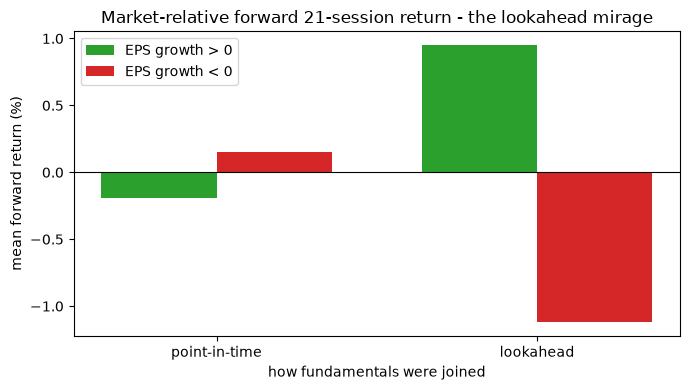

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
ax.bar(x - 0.18, bias["fwd_ret_eps_up_pct"], 0.36, label="EPS growth > 0", color="tab:green")
ax.bar(x + 0.18, bias["fwd_ret_eps_down_pct"], 0.36, label="EPS growth < 0", color="tab:red")
ax.set_xticks(x, bias.index)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Market-relative forward 21-session return - the lookahead mirage")
ax.set_xlabel("how fundamentals were joined")
ax.set_ylabel("mean forward return (%)")
ax.legend()
fig.tight_layout()

先読み版の「アルファ」は、丸ごと、市場より先に見た発表反応です。同じデータ、同じシグナル、
違うのはタイムスタンプ1つ。それだけでスプレッドが何もないところから現れます。実データでも、
できすぎたファンダメンタルズのバックテストはまさにこうやって生まれます。

## 5. 訂正: 元の研究を再現する

ファンダメンタルズは訂正されます。追記でキーを打つ PIT テーブルでは、訂正は*その報告時刻を
持つ新しい行*になります。履歴は編集されないので、古い見え方もクエリできるままです。監査
調整で STK003 の直近 EPS が35%上方修正されたとしましょう。

In [11]:
v_study = db.versions("fundamentals")[-1]["sequence"]  # pin: the version our study used

last = funda[funda["symbol"] == "STK003"].iloc[-1]
restated = pa.table(
    {
        "ts": pa.array([funda["ts"].max() + pd.Timedelta(days=3)], pa.timestamp("us", tz="UTC")),
        "period_end": pa.array([last["period_end"]], pa.timestamp("us", tz="UTC")),
        "symbol": ["STK003"],
        "eps": [round(last["eps"] * 1.35, 2)],
        "eps_growth": [None],
    }
).cast(FUNDA_SCHEMA)
db.append("fundamentals", restated, note="STK003 EPS restated +35% (audit adjustment)")

db.sql(
    f"""
    SELECT 'head (post-restatement)' AS view, eps, ts AS known_since
    FROM fundamentals
    WHERE symbol = 'STK003' ORDER BY ts DESC LIMIT 1
    """
).to_pandas()

,view,eps,known_since
0,head (post-restatement),2.3,2025-08-26 21:00:00+00:00


In [12]:
db.sql(
    f"""
    SELECT 'pinned v{v_study} (as studied)' AS view, eps, ts AS known_since
    FROM h5i('fundamentals', {v_study})
    WHERE symbol = 'STK003' ORDER BY ts DESC LIMIT 1
    """
).to_pandas()

,view,eps,known_since
0,pinned v1 (as studied),1.7,2025-08-16 21:00:00+00:00


リサーチの実行と一緒に `v_study`（か名前付きスナップショット）を記録しておけば、その研究は
永久にバイト単位で同一の入力に対して再実行できます。訂正はライブの利用に反映されつつ、
こちらの記録は書き換わりません。なお `asof_join` はテーブルの*先頭*に対して働きます。固定
したパネル全体を作り直すには、固定したバージョンを読み
（`db.read("fundamentals", version=v_study)` か SQL の `h5i(...)`）、それに対してジョイン
してください。

## まとめ

- ファンダメンタルズは**報告時刻**でキーを打ち、`period_end` は積み荷として持ちます。
  このスキーマ上の判断1つで、`asof_join` が既定でポイントインタイムになります。
- `asof_join(prices, fundamentals, 'ts', 'ts', 'symbol')` が PIT の仕掛けのすべてです。
  銘柄ごとの直近既知値に、「いつから既知か」の出所が `ts_right` として最初から付き、
  古すぎる数字は `tolerance` で拒めます。
- `period_end` で結合すると、何もしないシグナルに発表反応ぶんの太いスプレッドが付きました。
  先読みバイアスは主張ではなく、測った結果です。
- 訂正は編集ではなく追記です。バージョンを固定すれば（`h5i('t', v)`、`read(version=)`）、
  先頭が訂正後の見え方を配るあいだも、元の研究をそのまま再現できます。

In [13]:
db.close()